# LSTM Model for Vehicle Collisions

## Import Required Libraries

In [530]:
# Import libraries
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns
import torch
import torch.nn as nn
from torch.nn.utils.rnn import pad_sequence
from torch.utils.data import Dataset, DataLoader
import torch.optim as optim
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay, accuracy_score, precision_score, recall_score, f1_score
from tqdm import tqdm
from sklearn.preprocessing import StandardScaler

## Create New Features

In [531]:
# Min distance from any object to ego (bottom center of image)
def min_distance_to_ego(frame_df, image_width = 1280, image_height = 720):
    ego_x, ego_y = image_width / 2, image_height
    centers_x = (frame_df["x_min"] + frame_df["x_max"]) / 2
    centers_y = (frame_df["y_min"] + frame_df["y_max"]) / 2
    distances = np.sqrt((centers_x - ego_x) ** 2 + (centers_y - ego_y) ** 2)

    return distances.min() if not distances.empty else 0.0


# Change in max box area from previous frame
def max_box_area_growth(current_df, prev_df = None):
    current_areas = (current_df["x_max"] - current_df["x_min"]) * (current_df["y_max"] - current_df["y_min"])

    if prev_df is None or prev_df.empty:
        return 0.0
    
    prev_areas = (prev_df["x_max"] - prev_df["x_min"]) * (prev_df["y_max"] - prev_df["y_min"])
    
    # Ensure the prev_areas is properly handled
    if not prev_areas.empty:
        return (current_areas.max() - prev_areas.max())
    return 0.0

# Area of max box
def max_box_area(current_df):
    box_areas = (current_df["x_max"] - current_df["x_min"]) * (current_df["y_max"] - current_df["y_min"])

    return box_areas.max()


# Change in avg X-center of near objects
def delta_x_center_near_objects(current_df, prev_df = None, threshold_y_ratio = 0.75, image_height = 720):
    if prev_df is None:
        return 0.0

    current_close = current_df[(current_df["y_max"]) > image_height * threshold_y_ratio]
    prev_close = prev_df[(prev_df["y_max"]) > image_height * threshold_y_ratio]

    def avg_x(df):
        return ((df["x_min"] + df["x_max"]) / 2).mean() if not df.empty else 0.0

    return avg_x(current_close) - avg_x(prev_close)


# Count of large, low-positioned objects (danger zone)
def num_objects_in_danger_zone(frame_df, image_width = 1280, image_height = 720, y_threshold = 0.85, area_threshold = 1000):
    danger_zone_objects = frame_df[
        (frame_df["y_max"] > image_height * y_threshold) &
        ((frame_df["x_max"] - frame_df["x_min"]) * (frame_df["y_max"] - frame_df["y_min"]) > area_threshold)
    ]
    return len(danger_zone_objects)


# Binary flag for presence in danger zone
def danger_zone_flag(frame_df, image_width = 1280, image_height = 720, y_threshold = 0.85, area_threshold = 1000):
    return float(
        ((frame_df["y_max"] > image_height * y_threshold) &
         ((frame_df["x_max"] - frame_df["x_min"]) * (frame_df["y_max"] - frame_df["y_min"]) > area_threshold)
        ).any()
    )


def detect_sudden_appearance(curr_frame_df, prev_frame_df, image_height=720, y_threshold=0.85, area_threshold=1000):
    sudden_appearances = 0

    if prev_frame_df is None:
        return 0

    for _, obj in curr_frame_df.iterrows():
        x_center = (obj["x_min"] + obj["x_max"]) / 2
        y_center = (obj["y_min"] + obj["y_max"]) / 2
        area = (obj["x_max"] - obj["x_min"]) * (obj["y_max"] - obj["y_min"])

        # Close to bottom and big enough to matter
        if obj["y_max"] >= image_height * y_threshold and area > area_threshold:
            matches = prev_frame_df[
                (prev_frame_df["object_class"] == obj["object_class"]) &
                (abs((prev_frame_df["x_min"] + prev_frame_df["x_max"]) / 2 - x_center) < 50) &
                (abs((prev_frame_df["y_min"] + prev_frame_df["y_max"]) / 2 - y_center) < 50)
            ]

            if matches.empty:
                sudden_appearances += 1

    return sudden_appearances

## Extract Features from Each Frame

In [ ]:
def extract_frame_features(frame_df, prev_frame_df = None):

    relevant_classes = [2, 5, 7]
    frame_df = frame_df[frame_df["object_class"].isin(relevant_classes)]

    # Early exit if frame_df is empty
    if frame_df.empty:
        return torch.zeros(14)  # Return a zero tensor with the expected shape if no objects are detected

    features = []

    num_objects = len(frame_df)
    avg_conf = frame_df["confidence"].mean()
    avg_box_area = ((frame_df["x_max"] - frame_df["x_min"]) * (frame_df["y_max"] - frame_df["y_min"])).mean()

    # Define the number of desired object classes
    desired_size = 13
    class_counts = np.zeros(desired_size)

    # Count the occurrence of each class in the frame
    for cls in frame_df["object_class"]:
        cls = int(cls)
        if cls < desired_size:
            class_counts[cls] += 1

    # individual class counts
    car_count = (frame_df["object_class"] == 2).sum()
    bus_count = (frame_df["object_class"] == 7).sum()
    truck_count = (frame_df["object_class"] == 5).sum()

    # 6 new features
    min_dist = min_distance_to_ego(frame_df)
    box_growth = max_box_area_growth(frame_df, prev_frame_df)  # Pass prev_frame_df instead of prev_features
    lateral_shift = delta_x_center_near_objects(frame_df, prev_frame_df)
    num_danger_objects = num_objects_in_danger_zone(frame_df)
    binary_danger_indicator = danger_zone_flag(frame_df)
    sudden_appearances = detect_sudden_appearance(frame_df, prev_frame_df)
    largest_box_area = max_box_area(frame_df)

    # Combine into one feature tensor
    #raw_features = torch.tensor([num_objects, avg_conf, avg_box_area, min_dist, box_growth, lateral_shift] + class_counts.tolist(), dtype = torch.float32)
    raw_features = torch.tensor([num_objects, avg_conf, avg_box_area, largest_box_area, car_count, truck_count, bus_count], dtype = torch.float32)

    return raw_features

## Process Feature and Add Delta Features

In [553]:
def process_video_csv(csv_path, scaler = None):
    df = pd.read_csv(csv_path)

    if df.empty or "frame" not in df.columns:
        return torch.empty(0, 14)  # Return empty tensor if the DataFrame is empty or missing the 'frame' column

    sequences = []
    prev_features = None
    prev_frame_df = None  # Initialize this to None, it will store the previous DataFrame
    no_delta_indices = []

    for _, frame_df in df.groupby("frame"):
        current_features = extract_frame_features(frame_df, prev_frame_df)  # Pass prev_frame_df correctly

        if isinstance(current_features, np.ndarray):
            current_features = torch.tensor(current_features, dtype = torch.float32)

        # If there are previous features, compute the delta
        if prev_features is None:
            delta_features = torch.zeros_like(current_features)
            #delta_features = delta_features[:-len(no_delta_indices)]
        else:
            # Indices to include in the delta calculation
            included_delta_indices = [i for i in range(len(current_features)) if i not in no_delta_indices]

            # Only compute deltas for the included indices
            delta_features = (current_features - prev_features)[included_delta_indices]

        # Concatenate raw features and delta features
        full_features = torch.cat([current_features, delta_features])

        # Scale features if scaler is provided
        if scaler:
            full_features = torch.tensor(scaler.transform([full_features.numpy()])[0], dtype = torch.float32)

        sequences.append(full_features)

        # Update prev_features and prev_frame_df for the next frame
        prev_features = current_features
        prev_frame_df = frame_df  # Store the current frame_df for next iteration

    # If no sequences, return empty tensor with expected shape
    if not sequences:
        return torch.empty(0, 14)  # Return empty tensor if no sequences were created

    # Stack all sequences into a single tensor (num_frames x num_features)
    sequences = torch.stack(sequences)

    return sequences

## Load True Data Labels

In [534]:
import csv

# Load label CSV into a dictionary
label_dict = {}
with open("../../data/train_labels.csv", newline = "") as f:
    reader = csv.DictReader(f)
    for row in reader:
        label_dict[row["id"]] = int(row["target"])

## Split Data into Training, Validation, and Test Sets

In [535]:
from sklearn.model_selection import train_test_split

# Get all video directories
video_dirs = sorted([
    os.path.join("../data/yolo_processed_data", d)
    for d in os.listdir("../../data/yolo_processed_data")
    if os.path.isdir(os.path.join("../../data/yolo_processed_data", d))
])

# Initialize an empty list to store video_ids
video_ids = []

# Extract video IDs from the directory names, removing video_ prefix
for video_dir in video_dirs:
    video_id = os.path.basename(video_dir).replace("video_", "")
    video_ids.append(video_id)

# Ensure there are labels for all video IDs
for video_id in video_ids:
    if video_id not in label_dict:
        raise AssertionError(f"Label missing for video: {video_id}")
    

valid_video_ids = []
invalid_count = 0
all_detections = 0
video_count = 0

for video_id in video_ids:
    video_dir = os.path.join("../../data/yolo_processed_data", "video_" + video_id)
    detections_csv = os.path.join(video_dir, "detections.csv")

    try:
        df = pd.read_csv(detections_csv)
        all_detections += len(df)
        video_count += 1
        if (not df.empty and "frame" in df.columns and df["frame"].nunique() > 0 and len(df) >= 13):
            valid_video_ids.append(video_id)
        else:
            invalid_count += 1
    except:
        invalid_count += 1

print(f"Count of Videos With Invalid Detections: {invalid_count}")
print(f"Count of Videos With Valid Detections: {len(valid_video_ids)}")
print(f"Average Object Detections: {all_detections / video_count} objects")

# Split the video IDs
stratify_vals = [label_dict[vid] for vid in valid_video_ids]

train_ids, temp_ids = train_test_split(valid_video_ids, test_size = 0.2)

temp_stratify_vals = [label_dict[vid] for vid in temp_ids]
val_ids, test_ids = train_test_split(temp_ids, test_size = 0.5)


# Initialize empty lists to store the video directories
train_videos = []
val_videos = []
test_videos = []

# Populate the train_videos list with the corresponding directories
for video_id in train_ids:
    video_dir = os.path.join("../../data/yolo_processed_data", "video_" + video_id)
    train_videos.append(video_dir)

# Populate the val_videos list with the corresponding directories
for video_id in val_ids:
    video_dir = os.path.join("../../data/yolo_processed_data", "video_" + video_id)
    val_videos.append(video_dir)

# Populate the test_videos list with the corresponding directories
for video_id in test_ids:
    video_dir = os.path.join("../../data/yolo_processed_data", "video_" + video_id)
    test_videos.append(video_dir)

Count of Videos With Invalid Detections: 76
Count of Videos With Valid Detections: 1424
Average Object Detections: 188.79133333333334 objects


In [536]:
# Shape Sanity Check
print(f"-----Dataset Sizes-----")
print(f"Total Video Count: {len(valid_video_ids)}")
print(f"Train videos       - {len(train_videos)} Videos | {((len(train_videos) / len(valid_video_ids)) * 100):.2f}%")
print(f"Validation videos  - {len(val_videos)} Videos | {((len(val_videos) / len(valid_video_ids)) * 100):.2f}%")
print(f"Test videos        - {len(test_videos)} Videos | {((len(test_videos) / len(valid_video_ids)) * 100):.2f}%\n")


print(f"-----Sample Dataset Values-----")
print(f"Train Videos       - {train_videos[0:2]}")
print(f"Validation Videos  - {val_videos[0:2]}")
print(f"Test Videos        - {test_videos[0:2]}\n")



# Count labels in each set
def count_labels(video_ids, label_dict):
    counts = {0: 0, 1: 0}
    for video in video_ids:
        counts[label_dict[video]] += 1
    return counts

# Count and print for each set
train_counts = count_labels(train_ids, label_dict)
val_counts = count_labels(val_ids, label_dict)
test_counts = count_labels(test_ids, label_dict)


print(f"-----Label Counts Per Set-----")
print("Train Set - No Collision:", train_counts[0], "| Collision:", train_counts[1])
print("Val Set   - No Collision:", val_counts[0],   "| Collision:", val_counts[1])
print("Test Set  - No Collision:", test_counts[0],  "| Collision:", test_counts[1])

-----Dataset Sizes-----
Total Video Count: 1424
Train videos       - 1139 Videos | 79.99%
Validation videos  - 142 Videos | 9.97%
Test videos        - 143 Videos | 10.04%

-----Sample Dataset Values-----
Train Videos       - ['../../data/yolo_processed_data\\video_02027', '../../data/yolo_processed_data\\video_00734']
Validation Videos  - ['../../data/yolo_processed_data\\video_01918', '../../data/yolo_processed_data\\video_01538']
Test Videos        - ['../../data/yolo_processed_data\\video_01307', '../../data/yolo_processed_data\\video_00366']

-----Label Counts Per Set-----
Train Set - No Collision: 544 | Collision: 595
Val Set   - No Collision: 73 | Collision: 69
Test Set  - No Collision: 74 | Collision: 69


In [538]:
feature_scaler = StandardScaler()

all_train_features = []
no_delta_indices = []

for video_dir in train_videos:
    csv_path = os.path.join(video_dir, "detections.csv")
    df = pd.read_csv(csv_path)

    prev_features = None
    prev_frame_df = None

    for _, frame_df in df.groupby("frame"):
        raw_features = extract_frame_features(frame_df, prev_frame_df)
        
        # Concatenate raw features and delta features
        if prev_features is None:
            delta_features = torch.zeros_like(raw_features)
            #delta_features = delta_features[:-len(no_delta_indices)]
        else:
            # Indices to include in the delta calculation
            included_indices = [i for i in range(len(raw_features)) if i not in no_delta_indices]

            # Only compute deltas for the included indices
            delta_features = (raw_features - prev_features)[included_indices]

        full_features = torch.cat([raw_features, delta_features])
        
        # Ensure all full_features is the correct dimensions
        all_train_features.append(full_features.numpy())
        
        prev_features = raw_features
        prev_frame_df = frame_df 

all_train_features = np.array(all_train_features)

# Fit the scaler only after gathering all features
feature_scaler.fit(all_train_features)

StandardScaler()

In [539]:
# Sanity Check for Feature Shape
print(all_train_features.shape)

column_names = ["num_objects", "avg_conf", "avg_box_area", "largest_box_area", "car_count", "truck_count", "bus_count",
                "delta_num_objects", "delta_avg_conf", "delta_avg_box_area", "delta_largest_box_area", "delta_car_count", "delta_truck_count", "delta_bus_count",]

print(f"\n-----Example Frame 0 (Video {train_videos[0]})-----")
row = all_train_features[0]
for name, val in zip(column_names, row):
    print(f"{name}: {val:.2f}")

print(f"\n-----Example Frame 1 (Video {train_videos[0]})-----")
row = all_train_features[1]
for name, val in zip(column_names, row):
    print(f"{name}: {val:.2f}")

input_size = all_train_features.shape[1]

(40827, 14)

-----Example Frame 0 (Video ../../data/yolo_processed_data\video_02027)-----
num_objects: 1.00
avg_conf: 0.69
avg_box_area: 278827.78
largest_box_area: 278827.78
car_count: 1.00
truck_count: 0.00
bus_count: 0.00
delta_num_objects: 0.00
delta_avg_conf: 0.00
delta_avg_box_area: 0.00
delta_largest_box_area: 0.00
delta_car_count: 0.00
delta_truck_count: 0.00
delta_bus_count: 0.00

-----Example Frame 1 (Video ../../data/yolo_processed_data\video_02027)-----
num_objects: 2.00
avg_conf: 0.51
avg_box_area: 205210.08
largest_box_area: 271237.78
car_count: 1.00
truck_count: 0.00
bus_count: 0.00
delta_num_objects: 1.00
delta_avg_conf: -0.18
delta_avg_box_area: -73617.70
delta_largest_box_area: -7590.00
delta_car_count: 0.00
delta_truck_count: 0.00
delta_bus_count: 0.00


## Create Dataset and DataLoader

In [549]:
# Create a dataset class for the video sequences
class VideoDataset(Dataset):
    def __init__(self, video_dirs, label_dict, scaler = None):
        self.video_dirs = video_dirs
        self.label_dict = label_dict
        self.scaler = scaler

    def __len__(self):
        return len(self.video_dirs)
    
    def __getitem__(self, idx):
        while True:
            video_dir = self.video_dirs[idx]
            video_id = os.path.basename(video_dir)
            
            if video_id.startswith("video_"):
                video_id = video_id.replace("video_", "")

            video_id = video_id.zfill(5)

            label = self.label_dict.get(video_id, 0)

            csv_path = os.path.join(video_dir, "detections.csv")
            seq = process_video_csv(csv_path, scaler = self.scaler)

            if seq is None:
                idx = (idx + 1) % len(self.video_dirs)
                return self.__getitem__(idx)

            return seq, torch.tensor(label, dtype = torch.float32)
    
    
# Collate function to pad sequences and create batches
def collate_fn(batch):

    # Filter out samples with empty sequences
    batch = [(x, y) for x, y in batch if x.size(0) > 0]

    if len(batch) == 0:
        return None  # skip batch if empty

    batch.sort(key = lambda x: x[0].size(0), reverse = True)

    sequences, labels = zip(*batch)

    # Get the sequence lengths
    lengths = torch.tensor([len(seq) for seq in sequences])

    # Pad sequences with zero padding
    padded_seqs = pad_sequence(sequences, batch_first = True, padding_value = 0)  
    labels = torch.stack(labels)
    
    return padded_seqs, lengths, labels

# Create datasets for training and validation
train_dataset = VideoDataset(train_videos, label_dict, scaler = feature_scaler)
val_dataset = VideoDataset(val_videos, label_dict, scaler = feature_scaler)
test_dataset = VideoDataset(test_videos, label_dict, scaler = feature_scaler)

# Create DataLoader objects for training, validation, and testing
train_loader = DataLoader(train_dataset, batch_size = 4, shuffle = True, collate_fn = collate_fn)
val_loader = DataLoader(val_dataset, batch_size = 4, shuffle = False, collate_fn = collate_fn)
test_loader = DataLoader(test_dataset, batch_size = 4, shuffle = False, collate_fn = collate_fn)

## Define the LSTM Model

In [550]:
# Define the LSTM model for classification  
class LSTMClassifier(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, dropout):
        super().__init__()

        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.bidirectional = True
        self.num_directions = 2 if self.bidirectional else 1

        self.lstm = nn.LSTM(
            input_size = input_size,
            hidden_size = hidden_size,
            num_layers = num_layers,
            dropout = dropout if num_layers > 1 else 0.0,
            batch_first = True,
            bidirectional = self.bidirectional
        )

        self.fc = nn.Linear(hidden_size * self.num_directions, 1)
        self.sigmoid = nn.Sigmoid()
    
    def forward(self, x, lengths):
         # Pack padded sequence
        packed = nn.utils.rnn.pack_padded_sequence(x, lengths.cpu(), batch_first = True, enforce_sorted = False)
        packed_output, (hn, cn) = self.lstm(packed)

        hn = hn.view(self.num_layers, self.num_directions, x.size(0), self.hidden_size)

        if self.bidirectional:
            last_layer_forward = hn[-1, 0]
            last_layer_backward = hn[-1, 1]
            final_hidden = torch.cat([last_layer_forward, last_layer_backward], dim = 1)
        else:
            final_hidden = hn[-1, 0]  # just the last layer's forward hidden state

        out = self.fc(final_hidden)
        out = self.sigmoid(out)

        return out.squeeze()

## Training Loop

In [551]:
def train_model(model, train_loader, val_loader, criterion, optimizer, patience, device, epochs, print_epochs = False):
    model.to(device)

    # Initialize a previous loss value as a variable to compare validation losses to after each iteration
    previous_val_loss = float("inf")

    # Initialize loss lists and early stopping epochs
    train_losses = []
    val_losses = []
    early_stopping_epochs = 0

    # Iterate through epochs
    for epoch in range(epochs):
        # Training Phase
        model.train()
        running_train_loss = 0

        for batch in train_loader:
            if batch is None:
                continue

            x_batch, lengths, y_batch = batch   
            x_batch, lengths, y_batch = x_batch.to(device), lengths.to(device), y_batch.to(device)

            optimizer.zero_grad()
            outputs = model(x_batch, lengths)

            # Ensure that y_batch is in float format (binary classification: 0 or 1)
            y_batch = y_batch.float()

            # Ensure outputs are in the correct range [0, 1]
            loss = criterion(outputs, y_batch.squeeze())
            loss.backward()
            optimizer.step()

            running_train_loss += loss.item()

        avg_train_loss = running_train_loss / len(train_loader)
        train_losses.append(avg_train_loss)

        # Validation Phase
        model.eval()
        running_val_loss = 0
        all_preds = []
        all_labels = []

        with torch.no_grad():
            for batch in val_loader:
                if batch is None:
                    continue

                x_val, val_lengths, y_val = batch
                x_val, val_lengths, y_val = x_val.to(device), val_lengths.to(device), y_val.to(device)

                val_outputs = model(x_val, val_lengths)
                val_outputs = val_outputs.view(-1)

                # Ensure y_val is in float format (binary classification: 0 or 1)
                y_val = y_val.view(-1)

                val_loss = criterion(val_outputs, y_val)
                running_val_loss += val_loss.item()

                preds = (val_outputs > 0.5).float()
                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(y_val.cpu().numpy())

        avg_val_loss = running_val_loss / len(val_loader)
        val_losses.append(avg_val_loss)

        # Calculate accuracy
        val_accuracy = accuracy_score(all_labels, all_preds)

        if print_epochs:
            print(f"Epoch {epoch + 1}: Train Loss = {avg_train_loss:.4f} | Val Loss = {avg_val_loss:.4f} | Val Accuracy = {val_accuracy:.4f}")

        # Early stop if validation loss change is below tolerance
        if previous_val_loss > avg_val_loss:
            previous_val_loss = avg_val_loss
            early_stopping_epochs = 0
        else:
            early_stopping_epochs += 1

        # Break the loop if early stopping criteria is met
        if early_stopping_epochs >= patience:
            #print("Early stopping triggered.")
            break

    return train_losses, val_losses



## Tune Hyperparameters

In [543]:
# Function to iterate through differnt combinations of hyperparameters
def tune_lstm_hyperparameters(train_loader, val_loader, params, input_size, epochs, patience):
    best_params = None
    best_val_loss = float("inf")
    results = []

    # Calculate total combinations
    total_combinations = (
        len(params["hidden_size"]) *
        len(params["num_layers"]) *
        len(params["dropout"]) *
        len(params["learning_rate"]) *
        len(params["optimizer"])
    )

    with tqdm(total = total_combinations, desc = "Tuning") as progressbar:
        for hidden_size in tqdm(params["hidden_size"]):
            for dropout in params["dropout"]:
                for learning_rate in params["learning_rate"]:
                    for num_layers in params["num_layers"]:
                        for optimizer_name in params["optimizer"]:
                            
                            # Initialize the LSTM model with the current parameter combinations
                            model = LSTMClassifier(input_size = input_size,
                                                hidden_size = hidden_size,
                                                num_layers = num_layers,
                                                dropout = dropout)
                            
                            # Select the appropriate optimizer
                            if optimizer_name == "adam":
                                optimizer = optim.Adam(model.parameters(), lr = learning_rate, weight_decay = 1e-5)
                            elif optimizer_name == "rmsprop":
                                optimizer = optim.RMSprop(model.parameters(), lr = learning_rate)
                            else:
                                continue
                            
                            # Define criterion (loss function) and device
                            criterion = nn.BCELoss()
                            #criterion = nn.BCEWithLogitsLoss()
                            device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
                            
                            # Train the model
                            train_losses, val_losses = train_model(model, train_loader, val_loader, criterion, optimizer, patience, device, epochs)
                            final_val_loss = val_losses[-1] if val_losses else float("inf")


                            # Append results of the run to the dictionary
                            results.append({
                                "hidden_size": hidden_size,
                                "dropout": dropout,
                                "learning_rate": learning_rate,
                                "num_layers": num_layers,
                                "optimizer": optimizer_name,
                                "final_val_loss": final_val_loss
                            })


                            # Store the current parameters if they produce a lower val loss than the previous best
                            if final_val_loss < best_val_loss:
                                best_val_loss = final_val_loss
                                best_params = {
                                    "hidden_size": hidden_size,
                                    "dropout": dropout,
                                    "learning_rate": learning_rate,
                                    "num_layers": num_layers,
                                    "optimizer": optimizer_name
                                }


                            # Update progress bar
                            progressbar.update(1)

    print(f"Best Hyperparameters: {best_params}")
    print(f"Best Validation Loss: {best_val_loss:.2f}")
    
    return best_params, results


In [554]:
"""
params = {
    "hidden_size": [64, 128, 256],
    "dropout": [0.3, 0.4],
    "learning_rate": [0.001, 0.0001],
    "num_layers": [1, 2, 3],
    "optimizer": ["adam", "rmsprop"]
}
"""

params = {
    "hidden_size": [128],
    "dropout": [0.2],
    "learning_rate": [0.001],
    "num_layers": [4],
    "optimizer": ["adam"]
}


input_size = input_size
epochs = 10
patience = 5

best_params, results = tune_lstm_hyperparameters(train_loader, val_loader, params, input_size, epochs, patience)

Tuning:   0%|          | 0/1 [00:01<?, ?it/s]


KeyboardInterrupt: 

## Plot the Training and Validation Loss Curves for the Optimal Model

In [555]:
input_size = input_size

# Intialize the model with the tuned optimal parameters
model = LSTMClassifier(input_size = input_size, hidden_size = best_params["hidden_size"], num_layers = best_params["num_layers"], dropout = best_params["dropout"])


# Identify the optimal optimizer
if best_params["optimizer"] == "adam":
    optimizer = optim.Adam(model.parameters(), lr = best_params["learning_rate"])
    
elif best_params["optimizer"] == "rmsprop":
    optimizer = optim.RMSprop(model.parameters(), lr = best_params["learning_rate"])


# Determine number of epochs, level of patience, whether to print epoch outputs, loss function, and device
epochs = 100
patience = 6
print_epochs = True
criterion = nn.BCELoss()
#criterion = nn.BCEWithLogitsLoss()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Train the optimal model
train_losses, val_losses = train_model(model, train_loader, val_loader, criterion, optimizer, patience, device, epochs, print_epochs)


# Plot training and validation losses after all epochs are finished
plt.figure(figsize = (8, 6))
sns.lineplot(x = range(1, len(train_losses) + 1), y = train_losses, label = "Training Loss")
sns.lineplot(x = range(1, len(val_losses) + 1), y = val_losses, label = "Validation Loss")
plt.title("Training and Validation Loss Curves")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

Epoch 1: Train Loss = 0.6957 | Val Loss = 0.6932 | Val Accuracy = 0.5211
Epoch 2: Train Loss = 0.6933 | Val Loss = 0.6820 | Val Accuracy = 0.5563
Epoch 3: Train Loss = 0.6932 | Val Loss = 0.6871 | Val Accuracy = 0.5141


KeyboardInterrupt: 

## Save Model

In [ ]:
#torch.save(model.state_dict(), "./best_lstm_model.pth")

## Evaluate the Test Set

In [558]:

def evaluate_model(model, test_loader, device, criterion):
    model.eval()

    total_test_loss = 0.0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for x_batch, lengths, y_batch in test_loader:
            x_batch, lengths = x_batch.to(device), lengths.to(device)

            outputs = model(x_batch, lengths)

            # Make sure outputs and y_batch are the same shape
            if outputs.dim() == 0:
                outputs = outputs.unsqueeze(0)

            test_loss = criterion(outputs, y_batch)
            total_test_loss += test_loss.item() * x_batch.size(0)

            # Convert probabilities to binary predictions (0 or 1) based on threshold of 0.5
            preds = (outputs > 0.5).float()

            # Collect predictions and true labels
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(y_batch.cpu().numpy())

        # Calculate test loss
        avg_test_loss = (total_test_loss) / (len(test_loader.dataset))
        print(f"Test Loss: {avg_test_loss:.2f}")

        # Calculate test accuracy
        test_accuracy = accuracy_score(all_labels, all_preds)
        print(f"Test Accuracy: {test_accuracy:.2f}")


    return np.array(all_preds), np.array(all_labels)



criterion = nn.BCELoss()
#criterion = nn.BCEWithLogitsLoss()

y_pred, y_true = evaluate_model(model, test_loader, device, criterion)

precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)


Test Loss: 0.70
Test Accuracy: 0.48


In [561]:
# Log predictions
test_results = pd.DataFrame({
    "actual": y_true,
    "prediction": y_pred,
})

print(f"Model Metrics:")
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1 Score: {f1:.2f}")

test_results.head(10)

Model Metrics:
Precision: 0.48
Recall: 1.00
F1 Score: 0.65


,actual,prediction
0,0.0,1.0
1,1.0,1.0
2,1.0,1.0
3,1.0,1.0
4,0.0,1.0
5,0.0,1.0
6,1.0,1.0
7,0.0,1.0
8,1.0,1.0
9,1.0,1.0


## Confusion Matrix

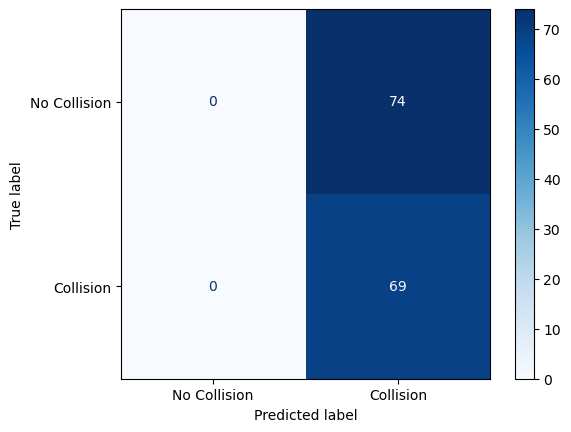

In [562]:
# Compute confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Display confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix = cm, display_labels = ["No Collision", "Collision"])
disp.plot(cmap = "Blues", values_format = "d")